# Notebook 1 — Analyse Exploratoire des Donnees (EDA)
## Projet : Return/Refund Propensity Classification — Olist E-Commerce

**Objectif de ce notebook :** Explorer le dataset Olist, comprendre la structure des donnees,
identifier les problemes de qualite et degager des insights utiles avant la modelisation.

---
### Plan
1. Chargement des donnees
2. Vue d'ensemble du dataset
3. Analyse des valeurs manquantes
4. Distribution de la variable cible proxy
5. Analyse des variables numeriques
6. Analyse des variables categorielles
7. Analyse temporelle
8. Correlations
9. Conclusions de l'EDA

## 0. Imports & Configuration

In [1]:
# --- Librairies standard ---
import pandas as pd
import numpy as np
import warnings
import sys
import os

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Configuration globale ---
warnings.filterwarnings('ignore')          # Masquer les warnings non-critiques
pd.set_option('display.max_columns', 50)   # Afficher jusqu'à 50 colonnes
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 décimales pour les floats

# Style des graphiques
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

# Ajouter le dossier racine au PATH pour pouvoir importer src/
sys.path.append(os.path.abspath('..'))

print('✅ Imports réussis')

✅ Imports réussis


---
## 1. Chargement des Données

On charge le DataFrame maître pré-généré `data/master.csv`.

In [2]:
# Charger le DataFrame maître pré-généré
df = pd.read_csv('../data/master.csv')

# Aperçu rapide
print(f"\nShape du DataFrame : {df.shape}")


Shape du DataFrame : (99441, 22)


---
## 2. Vue d'Ensemble du Dataset

In [3]:
# Afficher les 5 premières lignes
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,review_score,review_comment_message,payment_value,payment_installments,payment_type,item_count,total_price,total_freight,seller_id,product_category_name_english,product_weight_g,product_photos_qty
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,sao paulo,SP,4.00,"Não testei o produto ainda, mas ele veio corre...",38.71,1.00,voucher,1.00,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,housewares,500.00,4.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,barreiras,BA,4.00,Muito bom o produto.,141.46,1.00,boleto,1.00,118.70,22.76,289cdb325fb7e7f891c38608bf9e0962,perfumery,400.00,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,vianopolis,GO,5.00,NaN,179.12,3.00,credit_card,1.00,159.90,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,auto,420.00,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,sao goncalo do amarante,RN,5.00,O produto foi exatamente o que eu esperava e e...,72.20,1.00,credit_card,1.00,45.00,27.20,66922902710d126a0e7d26b0e3805106,pet_shop,450.00,3.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,santo andre,SP,5.00,NaN,28.62,1.00,credit_card,1.00,19.90,8.72,2c9e548be18521d1c43cde1c582c6de8,stationery,250.00,4.00


In [4]:
# Informations sur les types de données et les valeurs non-nulles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   customer_city                  99441 non-null  object 
 9   customer_state                 99441 non-null  object 
 10  review_score                   98673 non-null  float64
 11  review_comment_message         40774 non-null  object 
 12  payment_value                  99440 non-null 

In [5]:
# Statistiques descriptives pour les colonnes numériques
# count, mean, std, min, 25%, 50%, 75%, max
df.describe()

,review_score,payment_value,payment_installments,item_count,total_price,total_freight,product_weight_g,product_photos_qty
count,98673.00,99440.00,99440.00,98666.00,98666.00,98666.00,98650.00,97250.00
mean,4.09,160.99,2.93,1.14,137.75,22.82,2102.62,2.25
std,1.35,221.95,2.72,0.54,210.65,21.65,3765.68,1.75
min,1.00,0.00,0.00,1.00,0.85,0.00,0.00,1.00
25%,4.00,62.01,1.00,1.00,45.90,13.85,300.00,1.00
50%,5.00,105.29,2.00,1.00,86.90,17.17,700.00,2.00
75%,5.00,176.97,4.00,1.00,149.90,24.04,1800.00,3.00
max,5.00,13664.08,24.00,21.00,13440.00,1794.96,40425.00,20.00


In [6]:
# Distribution des statuts de commande
print('Distribution des statuts de commande :')
print(df['order_status'].value_counts())

# Pour la target proxy return/refund, on conserve delivered + canceled + unavailable

Distribution des statuts de commande :
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


---
## 3. Analyse des Valeurs Manquantes

Identifier les NaN est une étape critique : ils peuvent biaiser les modèles si mal gérés.

In [7]:
# Calcul du taux de valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'nb_manquants': missing, 'pct_manquants': missing_pct})
missing_df = missing_df[missing_df['nb_manquants'] > 0].sort_values('pct_manquants', ascending=False)

print('Colonnes avec des valeurs manquantes :')
print(missing_df)

Colonnes avec des valeurs manquantes :
                               nb_manquants  pct_manquants
review_comment_message                58667          59.00
order_delivered_customer_date          2965           2.98
product_category_name_english          2212           2.22
product_photos_qty                     2191           2.20
order_delivered_carrier_date           1783           1.79
product_weight_g                        791           0.80
item_count                              775           0.78
total_price                             775           0.78
total_freight                           775           0.78
seller_id                               775           0.78
review_score                            768           0.77
order_approved_at                       160           0.16
payment_value                             1           0.00
payment_installments                      1           0.00
payment_type                              1           0.00


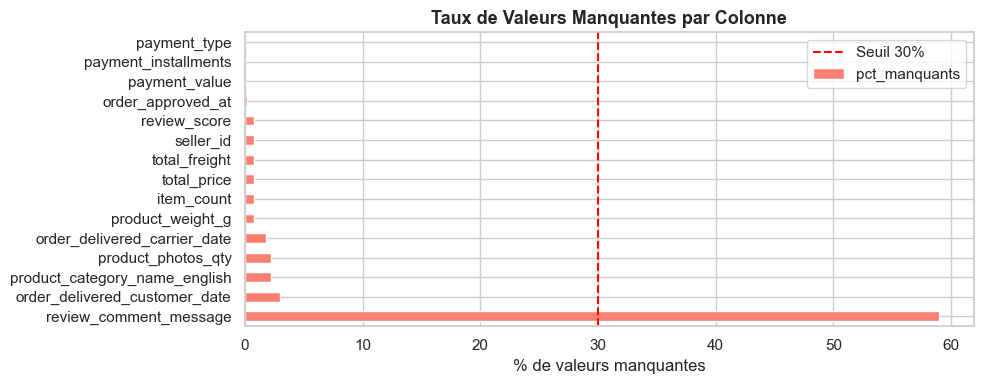

In [8]:
# Visualisation des valeurs manquantes
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['pct_manquants'].plot(kind='barh', ax=ax, color='salmon')
    ax.set_xlabel('% de valeurs manquantes')
    ax.set_title('Taux de Valeurs Manquantes par Colonne', fontweight='bold')
    ax.axvline(x=30, color='red', linestyle='--', label='Seuil 30%')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Aucune valeur manquante détectée dans le DataFrame fusionné.')

---
## 4. Distribution de la Variable Cible Proxy (Return/Refund Risk — Pré-livraison)

Comprendre la distribution de la cible proxy est essentiel pour :
- Quantifier le desequilibre des classes
- Valider les hypotheses de modeling
- Orienter les strategies de mitigation

Definition pre-livraison de la cible :
- `1` si la commande est `canceled` ou `unavailable`
- `0` sinon

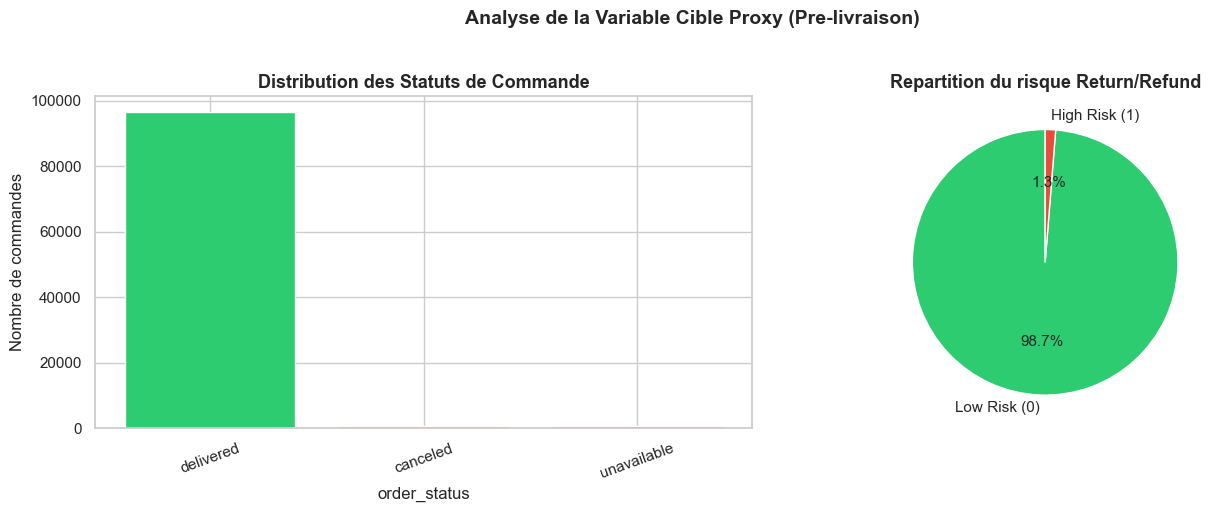


Desequilibre des classes : low risk=96,478 | high risk=1,234
Ratio low/high : 78.2:1


In [9]:
# Construire une cible proxy return/refund risk (pre-livraison)
df_scope = df[df['order_status'].isin(['delivered', 'canceled', 'unavailable'])].copy()
df_scope['is_return_refund_risk'] = (
    df_scope['order_status'].isin(['canceled', 'unavailable'])
).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution par statut
status_counts = df_scope['order_status'].value_counts()
axes[0].bar(status_counts.index, status_counts.values, color=['#2ecc71', '#e67e22', '#e74c3c'])
axes[0].set_xlabel('order_status')
axes[0].set_ylabel('Nombre de commandes')
axes[0].set_title('Distribution des Statuts de Commande', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Graphique 2 : Distribution binaire du risque
risk_counts = df_scope['is_return_refund_risk'].value_counts().sort_index()
labels = ['Low Risk (0)', 'High Risk (1)']
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(risk_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Repartition du risque Return/Refund', fontweight='bold')

plt.suptitle('Analyse de la Variable Cible Proxy (Pre-livraison)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nDesequilibre des classes : low risk={risk_counts.get(0,0):,} | high risk={risk_counts.get(1,0):,}")
print(f"Ratio low/high : {risk_counts.get(0,1)/max(risk_counts.get(1,1),1):.1f}:1")

# Conserver un DataFrame de reference pour les analyses suivantes
df_delivered = df_scope.copy()

---
## 5. Analyse des Variables Numériques

Étude des distributions et des outliers pour les variables quantitatives clés.

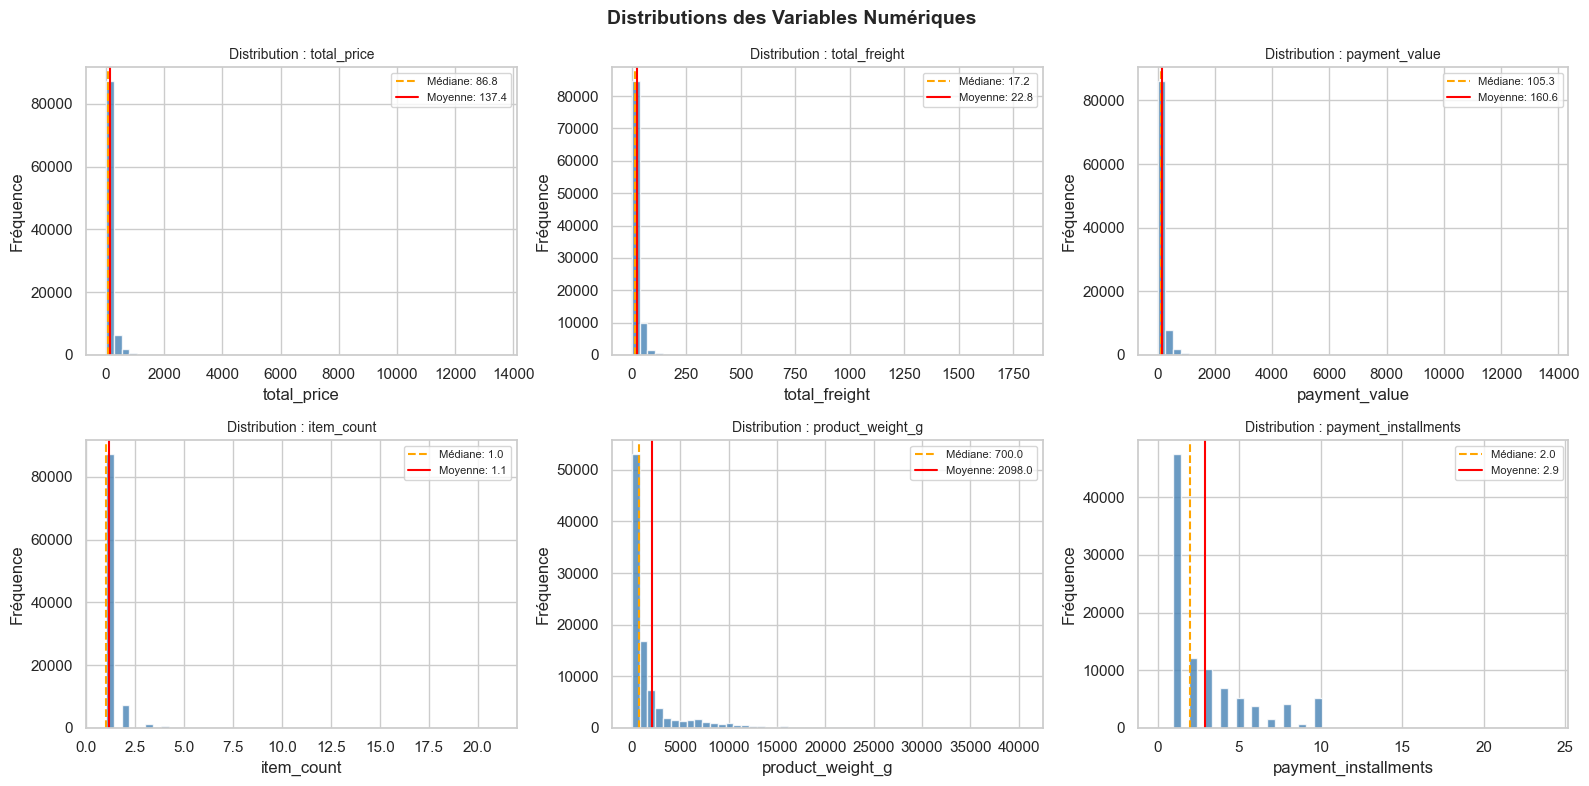

In [10]:
# Colonnes numériques à analyser
numeric_cols = ['total_price', 'total_freight', 'payment_value',
                 'item_count', 'product_weight_g', 'payment_installments']

# Filtrer uniquement les colonnes existantes
numeric_cols = [c for c in numeric_cols if c in df_delivered.columns]

# Histogrammes avec boîtes à moustaches
fig, axes = plt.subplots(2, len(numeric_cols)//2, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df_delivered[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution : {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    # Ajouter médiane et moyenne pour comparer
    axes[i].axvline(data.median(), color='orange', linestyle='--', label=f'Médiane: {data.median():.1f}')
    axes[i].axvline(data.mean(),   color='red',    linestyle='-',  label=f'Moyenne: {data.mean():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distributions des Variables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

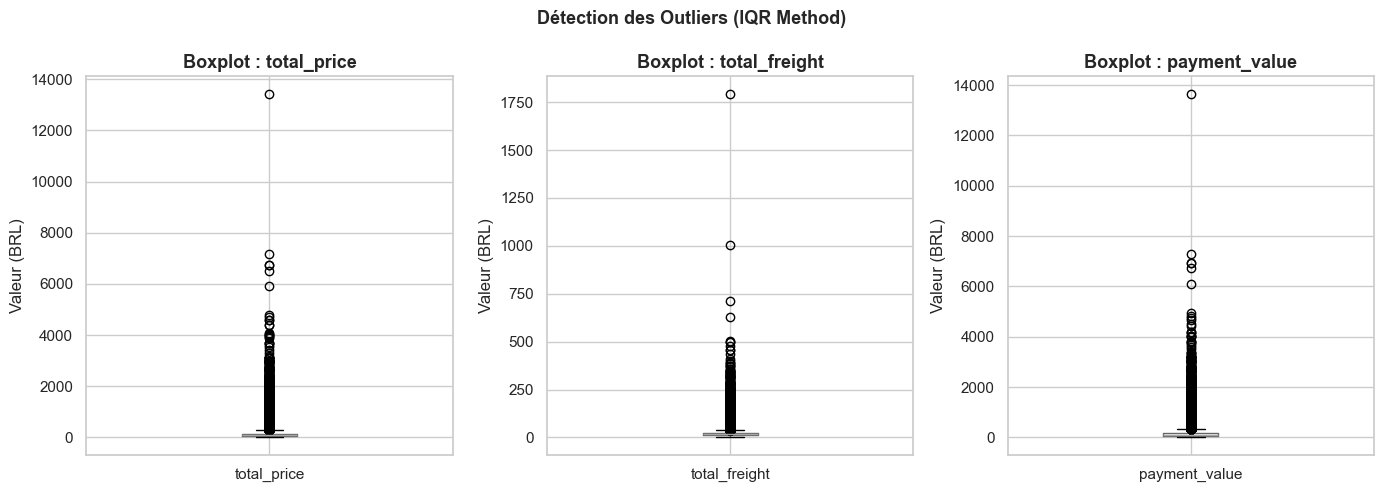


Nombre d'outliers détectés (méthode IQR):
  total_price              : 7,721 outliers (7.9%)
  total_freight            : 9,747 outliers (10.0%)
  payment_value            : 7,705 outliers (7.9%)


In [11]:
# Boxplots pour détecter les outliers
# Un outlier est une valeur anormalement éloignée du reste (au-delà de 1.5 × IQR)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cols_to_plot = ['total_price', 'total_freight', 'payment_value']
cols_to_plot = [c for c in cols_to_plot if c in df_delivered.columns]

for i, col in enumerate(cols_to_plot):
    df_delivered.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Boxplot : {col}', fontweight='bold')
    axes[i].set_ylabel('Valeur (BRL)')

plt.suptitle('Détection des Outliers (IQR Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantifier les outliers avec la méthode IQR
print('\nNombre d\'outliers détectés (méthode IQR):')
for col in cols_to_plot:
    Q1 = df_delivered[col].quantile(0.25)
    Q3 = df_delivered[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_delivered[(df_delivered[col] < Q1 - 1.5*IQR) | (df_delivered[col] > Q3 + 1.5*IQR)]
    print(f'  {col:25s}: {len(outliers):,} outliers ({len(outliers)/len(df_delivered)*100:.1f}%)')

---
## 6. Analyse des Variables Catégorielles

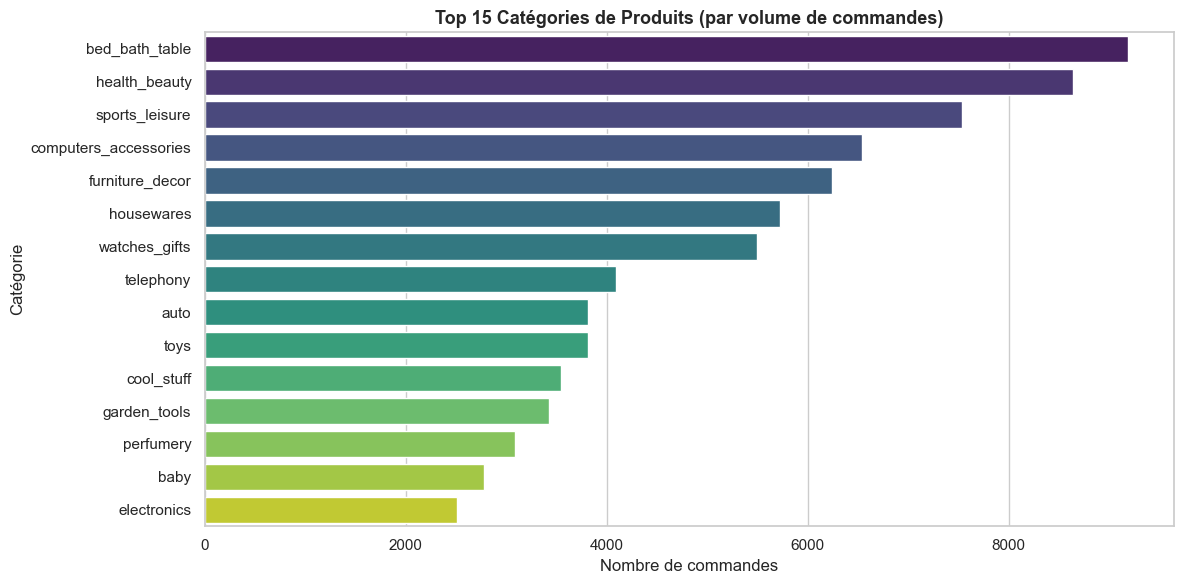

In [12]:
# Top 15 catégories de produits par nombre de commandes
if 'product_category_name_english' in df_delivered.columns:
    top_categories = (df_delivered['product_category_name_english']
                      .value_counts().head(15))

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
    plt.title('Top 15 Catégories de Produits (par volume de commandes)', fontweight='bold')
    plt.xlabel('Nombre de commandes')
    plt.ylabel('Catégorie')
    plt.tight_layout()
    plt.show()

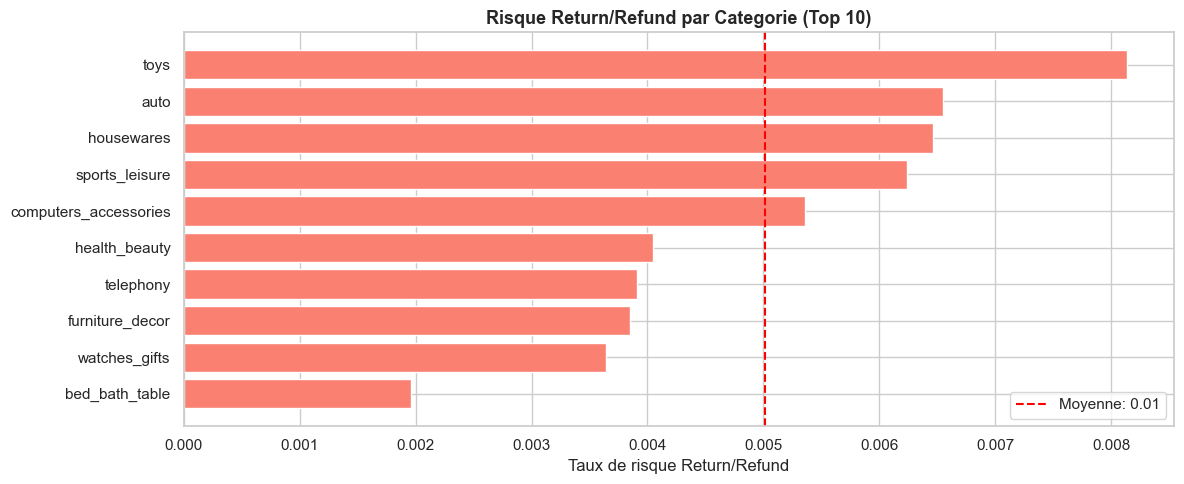

In [13]:
# Risque return/refund par categorie de produit (Top 10)
if 'product_category_name_english' in df_delivered.columns:
    top10_cats = df_delivered['product_category_name_english'].value_counts().head(10).index
    df_top10 = df_delivered[df_delivered['product_category_name_english'].isin(top10_cats)]

    risk_by_cat = df_top10.groupby('product_category_name_english')['is_return_refund_risk'].mean().sort_values()

    plt.figure(figsize=(12, 5))
    plt.barh(risk_by_cat.index, risk_by_cat.values, color='salmon')
    plt.axvline(x=risk_by_cat.mean(), color='red', linestyle='--', label=f'Moyenne: {risk_by_cat.mean():.2f}')
    plt.xlabel('Taux de risque Return/Refund')
    plt.title('Risque Return/Refund par Categorie (Top 10)', fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()

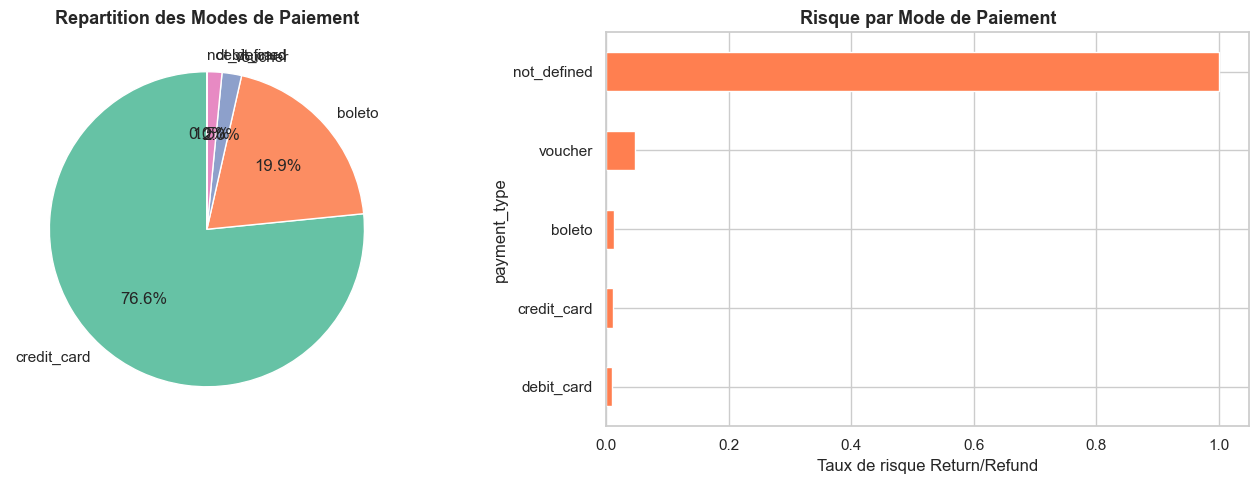

In [14]:
# Distribution des modes de paiement
if 'payment_type' in df_delivered.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    payment_counts = df_delivered['payment_type'].value_counts()
    axes[0].pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Repartition des Modes de Paiement', fontweight='bold')

    risk_by_payment = df_delivered.groupby('payment_type')['is_return_refund_risk'].mean().sort_values()
    risk_by_payment.plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_xlabel('Taux de risque Return/Refund')
    axes[1].set_title('Risque par Mode de Paiement', fontweight='bold')

    plt.tight_layout()
    plt.show()

---
## 7. Analyse Temporelle

Etude des tendances dans le temps : volumes de commandes et risque moyen par mois.

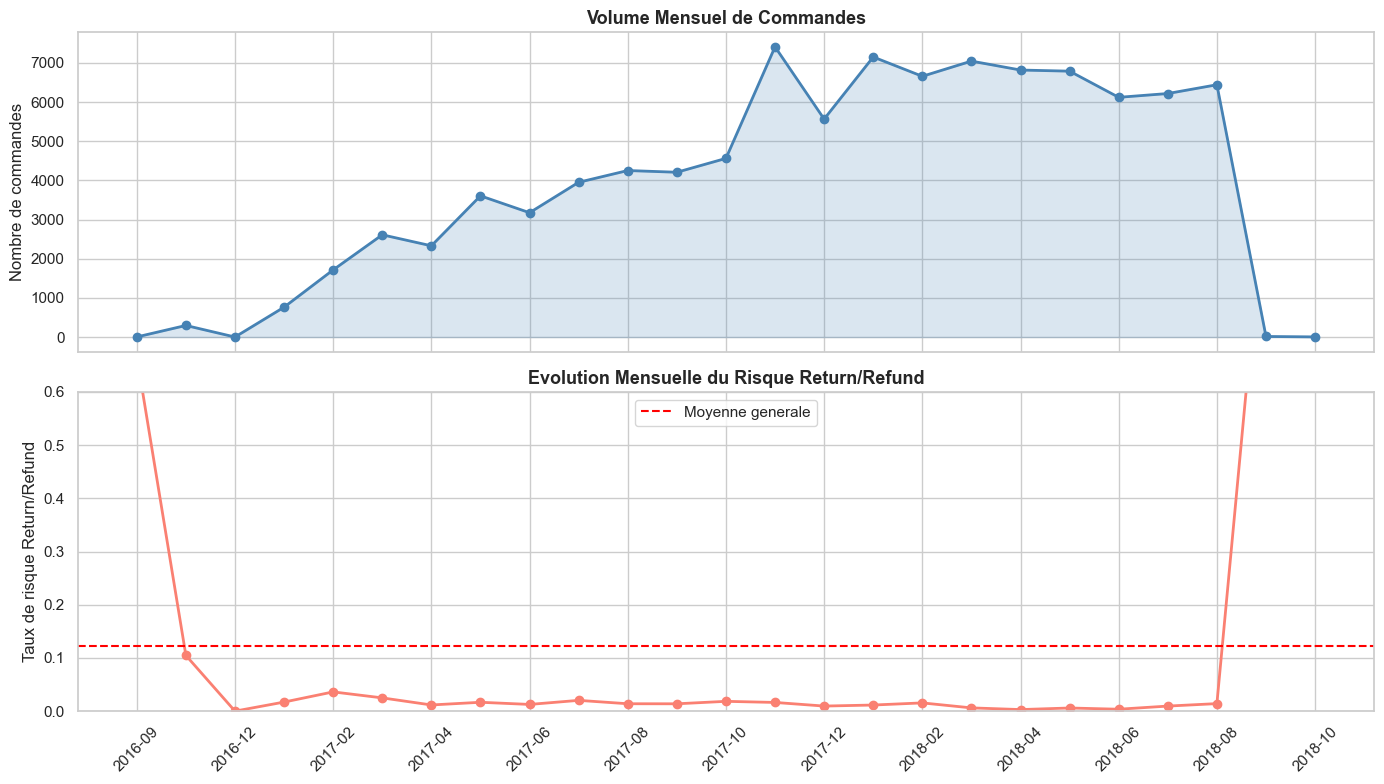

In [15]:
df_delivered['order_purchase_timestamp'] = pd.to_datetime(
    df_delivered['order_purchase_timestamp'], errors='coerce'
)

df_delivered['year_month'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')
monthly = df_delivered.groupby('year_month').agg(
    nb_commandes=('order_id', 'count'),
    taux_risque=('is_return_refund_risk', 'mean')
).reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly['year_month'], monthly['nb_commandes'], marker='o', linewidth=2, color='steelblue')
axes[0].fill_between(range(len(monthly)), monthly['nb_commandes'], alpha=0.2, color='steelblue')
axes[0].set_ylabel('Nombre de commandes')
axes[0].set_title('Volume Mensuel de Commandes', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['year_month'], monthly['taux_risque'], marker='o', linewidth=2, color='salmon')
axes[1].axhline(y=monthly['taux_risque'].mean(), color='red', linestyle='--', label='Moyenne generale')
axes[1].set_ylabel('Taux de risque Return/Refund')
axes[1].set_title('Evolution Mensuelle du Risque Return/Refund', fontweight='bold')
axes[1].set_ylim(0.0, 0.6)
axes[1].legend()
plt.xticks(range(0, len(monthly), 2), monthly['year_month'][::2], rotation=45)

plt.tight_layout()
plt.show()

---
## 8. Analyse des Correlations

La heatmap de correlation montre les relations lineaires entre variables numeriques.
On inclut la cible proxy `is_return_refund_risk` pour identifier les signaux utiles.

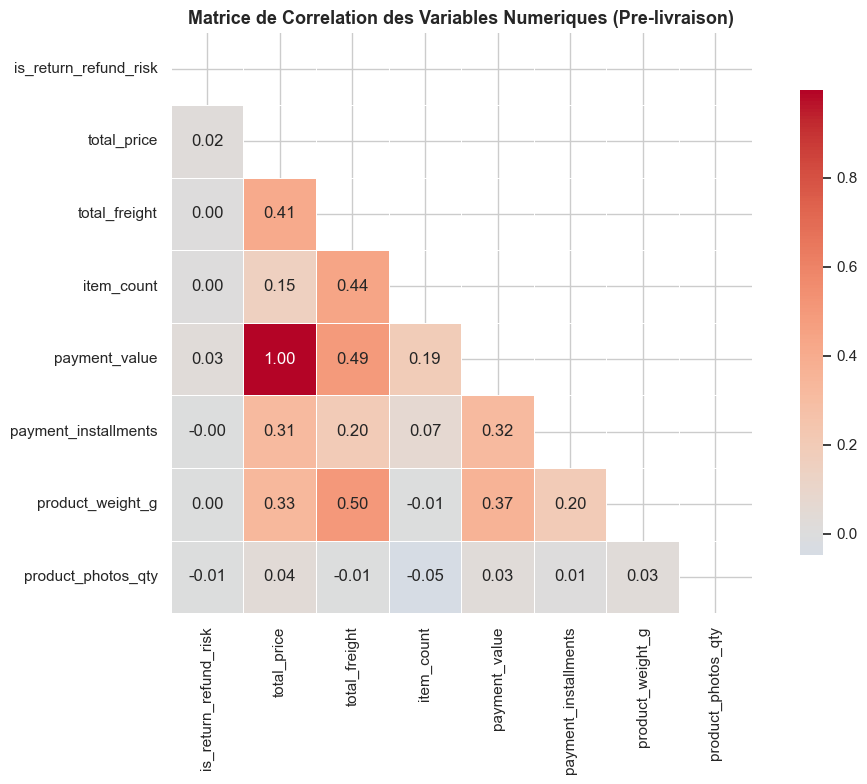


Correlations avec is_return_refund_risk (ordre decroissant):
payment_value           0.03
total_price             0.02
product_photos_qty     -0.01
item_count              0.00
payment_installments   -0.00
total_freight           0.00
product_weight_g        0.00
Name: is_return_refund_risk, dtype: float64


In [16]:
# Correlations uniquement sur des variables disponibles avant livraison
corr_cols = [
    'is_return_refund_risk',
    'total_price',
    'total_freight',
    'item_count',
    'payment_value',
    'payment_installments',
    'product_weight_g',
    'product_photos_qty',
]
corr_cols = [c for c in corr_cols if c in df_delivered.columns]

corr_matrix = df_delivered[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de Correlation des Variables Numeriques (Pre-livraison)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelations avec is_return_refund_risk (ordre decroissant):')
print(corr_matrix['is_return_refund_risk'].drop('is_return_refund_risk').sort_values(key=abs, ascending=False))

Toutes les correlations avec la cible is_return_refund_risk :
payment_value           0.03
total_price             0.02
product_photos_qty     -0.01
item_count              0.00
payment_installments   -0.00
total_freight           0.00
product_weight_g        0.00
Name: is_return_refund_risk, dtype: float64


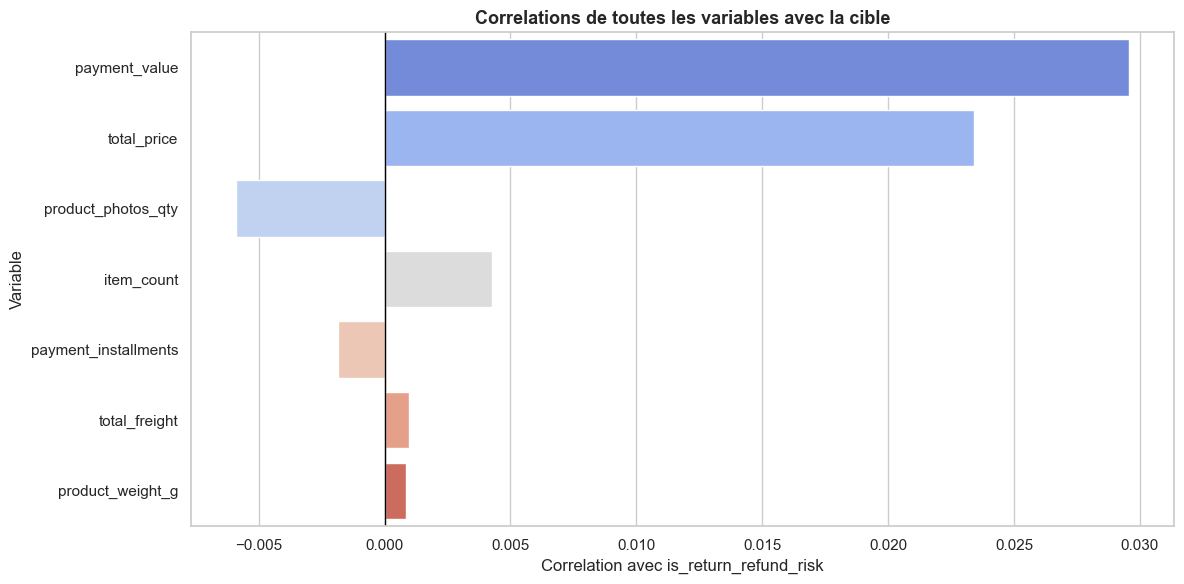

In [17]:
# Toutes les variables corrélées à la cible is_return_refund_risk
if 'corr_matrix' not in globals():
    corr_cols = [c for c in df_delivered.columns if pd.api.types.is_numeric_dtype(df_delivered[c])]
    if 'is_return_refund_risk' in df_delivered.columns and 'is_return_refund_risk' not in corr_cols:
        corr_cols = ['is_return_refund_risk'] + corr_cols
    corr_matrix = df_delivered[corr_cols].corr()

target_corr = corr_matrix['is_return_refund_risk'].drop('is_return_refund_risk').sort_values(key=abs, ascending=False)

print('Toutes les correlations avec la cible is_return_refund_risk :')
print(target_corr)

plt.figure(figsize=(12, max(6, 0.35 * len(target_corr))))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.axvline(0, color='black', linewidth=1)
plt.title('Correlations de toutes les variables avec la cible', fontweight='bold')
plt.xlabel('Correlation avec is_return_refund_risk')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

---
## 9. Conclusions de l'EDA

Synthèse des observations clés avant de passer au preprocessing.

### Points cles identifies

**Qualite des donnees :**
- Valeurs manquantes surtout dans `review_comment_message`, `product_category_name`, et certaines dates.
- Presence d'outliers sur prix et frais de port.
- Colonnes de dates a convertir avant modeling.

**Variable cible proxy :**
- Cible `is_return_refund_risk` desequilibree (majorite low risk).
- Definition pre-livraison : `order_status` dans `{canceled, unavailable}`.
- Utiliser `class_weight='balanced'` ou un ajustement de seuil.

**Features prometteuses (pre-livraison) :**
- `freight_ratio`
- `payment_installments`
- `item_count`
- signaux de paiement et categorie produit

**Tendances temporelles :**
- Variation du volume de commandes selon les mois.
- Variation du taux de risque selon les periodes.

**Prochaine etape :** `02_Modeling.ipynb` pour entrainer les versions finales;
les essais de parametres sont dans `brouillon_essai.ipynb`.